# Determination of the distance to Pleiades using TOPCAT

This tutorial has been adapted from the [TOPCAT tutorial](https://zenodo.org/records/10720670) developed by the Spanish Virtual Observatory. We will use data from the [Tycho-Gaia Astrometric Solution (TGAS)](https://cdsarc.cds.unistra.fr/viz-bin/cat/I/337)  catalogue to determine the mean parallax of the stars in the Pleiades open star cluster, thus obtaining its distance. For this, we will access photometric catalogues, cross-match tables, filter sources, create subsets, and represent the results using different kind of plots.

## Science case

Stars do not form isolated in space. They are born in large groups from the same natal interstellar cloud. We call them **star clusters**. Because all the stars in a given open cluster have the same origin,
they share important properties, having the same age, similar chemistry, and the same kinematics.

The Pleiades (M45) is one of the star clusters nearest to Earth. It is visible by naked eye from both
hemispheres and contains thousands of stars.

## Workflow

| Block | What we do |
|:--|:--|
| **Block 0** | Setup: install and import the packages |
| **Block 1** | Data discovery: download TGAS data around the Pleiades |
| **Block 2** | Select comoving sources using proper motions |
| **Block 3** | Identify the Pleiades members using parallaxes |
| **Block 4** | Calculate the distance to the Pleiades |
| **Bonus** | 2MASS photometry, comparison with another study, and sky view with Aladin |

**How to use this notebook:** run the cells one by one, from top to bottom, with `Shift + Enter`.

---
## Block 0: Setup

First, we install all the packages we will need. (If you already have them installed, you can skip this cell.)

In [ ]:
!pip install -r requirements_topcat.txt

Now we import them:

In [27]:
# Standard Library
from pathlib import Path

# Astronomy tools
from astropy import units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table

# Access astronomical databases
import pyvo
from astroquery.simbad import Simbad
from astroquery.vizier import Vizier
from astroquery.xmatch import XMatch
from astroquery.vo_conesearch import conesearch
from astroquery.mast import Catalogs

# Sky visualization
from ipyaladin import Aladin

#Other tools
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import numpy as np
from scipy.stats import norm
import pandas as pd
import plotly.express as px
import seaborn as sns

Finally, we choose a common style for all the plots in this notebook:

In [48]:
# Common style for all the plots (white background with a light grid)
sns.set_theme(style="whitegrid", context="notebook")

# One colour per sample, used in every plot so they are easy to follow
COLORS = {
    "all": "#9aa5b1",       # all TGAS sources (grey)
    "comoving": "#12a5ea",  # comoving sources (blue)
    "cluster": "#dc4c24",   # parallax-selected cluster members (red)
    "good": "#e4cc1a",      # members with good parallaxes (gold)
}

---
## Block 1: Data discovery

Let's begin by acquiring TGAS data in the Pleiades region using astroquery. We ask for all the sources within 5 degrees of the cluster centre.

In [30]:
# Query the TGAS catalogue around the Pleiades (the radius is given in degrees)
catalog_data = Catalogs.query_object(catalog="TGAS", objectname='Pleiades', radius=5)

# Round the columns we are going to use, so the tables are easier to read
catalog_data['ra'] = catalog_data['ra'].round(6)
catalog_data['dec'] = catalog_data['dec'].round(6)
catalog_data['pmra'] = catalog_data['pmra'].round(2)
catalog_data['pmdec'] = catalog_data['pmdec'].round(2)
catalog_data['parallax'] = catalog_data['parallax'].round(2)
catalog_data['parallax_error'] = catalog_data['parallax_error'].round(2)
catalog_data['phot_g_mean_mag'] = catalog_data['phot_g_mean_mag'].round(2)

# Show the most relevant columns
catalog_data[['hip', 'tycho2_id', 'ra', 'dec', 'parallax', 'parallax_error','pmra','pmdec','phot_g_mean_mag']]

hip,tycho2_id,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_mag
str5,str11,float64,float64,float64,float64,float64,float64,float64
--,1800-1908-1,56.613754,24.254813,7.74,0.32,19.96,-44.29,7.36
--,1800-1974-1,56.557353,24.196562,7.56,0.27,17.72,-12.33,7.24
--,1800-1935-1,56.791982,24.276466,7.15,0.43,20.43,-43.95,9.33
--,1800-1607-1,56.830695,24.138932,7.64,0.3,17.88,-43.46,8.24
--,1800-2201-1,56.837754,24.11608,7.88,0.46,20.89,-44.68,6.33
--,1800-1579-1,56.767652,23.995026,7.13,0.32,22.72,-44.93,8.31
17704,--,56.872808,24.288143,7.57,0.4,18.48,-46.91,6.83
--,1799-79-1,56.465239,24.038689,7.41,0.25,19.72,-44.88,7.84
--,1799-26-1,56.359021,24.034958,8.23,0.3,21.31,-46.95,8.01


Let's visualize the sources we have obtained in a **proper motion diagram**. Note the overdensity around (pmRA, pmDec) = (20, -45) mas/yr: those stars move together in the sky.

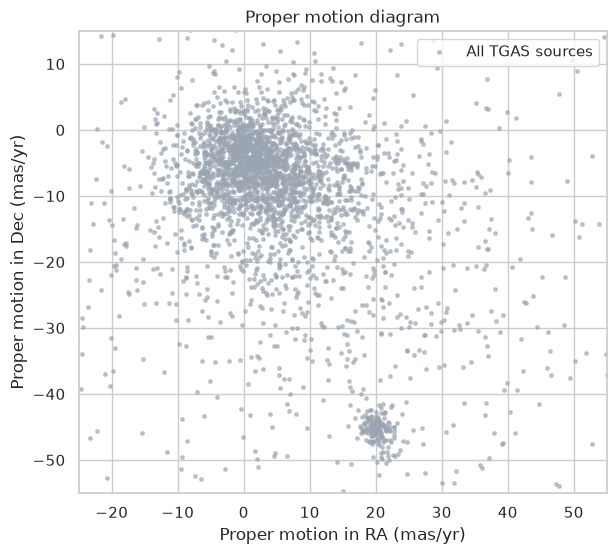

In [31]:
fig, ax = plt.subplots(figsize=(8, 6))

# Each point is one star, placed according to its proper motion
ax.scatter(catalog_data['pmra'], catalog_data['pmdec'],
           s=6, color=COLORS["all"], alpha=0.6, label="All TGAS sources")

ax.set_xlim(-25, 55)
ax.set_ylim(-55, 15)
ax.set_aspect("equal")  # same scale on both axes, so the clump is not distorted
ax.set_xlabel("Proper motion in RA (mas/yr)")
ax.set_ylabel("Proper motion in Dec (mas/yr)")
ax.set_title("Proper motion diagram")
ax.legend(loc="upper right")
plt.show()

---
## Block 2: Select comoving sources

We will select Pleiades candidate members applying some filtering criteria in PMRA and PMDEC (in the original tutorial the selection of the region is done by hand):

* 15 < pmRA < 25 mas/yr
* -50 < pmDec < -40 mas/yr

In [34]:
# Limits of the selection box in proper motion (mas/yr)
pmra_min, pmra_max = 15, 25
pmdec_min, pmdec_max = -50, -40

# Select comoving sources
position_mask = (
    (catalog_data['pmra'] > pmra_min) &
    (catalog_data['pmra'] < pmra_max) &
    (catalog_data['pmdec'] > pmdec_min) &
    (catalog_data['pmdec'] < pmdec_max)
)

comoving = catalog_data[position_mask]

comoving[['hip', 'tycho2_id', 'ra', 'dec', 'parallax', 'parallax_error','pmra','pmdec','phot_g_mean_mag']]

hip,tycho2_id,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_mag
str5,str11,float64,float64,float64,float64,float64,float64,float64
--,1800-1908-1,56.613754,24.254813,7.74,0.32,19.96,-44.29,7.36
--,1800-1935-1,56.791982,24.276466,7.15,0.43,20.43,-43.95,9.33
--,1800-1607-1,56.830695,24.138932,7.64,0.3,17.88,-43.46,8.24
--,1800-2201-1,56.837754,24.11608,7.88,0.46,20.89,-44.68,6.33
--,1800-1579-1,56.767652,23.995026,7.13,0.32,22.72,-44.93,8.31
17704,--,56.872808,24.288143,7.57,0.4,18.48,-46.91,6.83
--,1799-79-1,56.465239,24.038689,7.41,0.25,19.72,-44.88,7.84
--,1799-26-1,56.359021,24.034958,8.23,0.3,21.31,-46.95,8.01
--,1800-1567-1,56.851815,23.91449,7.65,0.3,18.85,-43.76,7.31


Now, the found candidates are overplotted in the previous proper motion diagram. The dashed box shows the region we have selected.

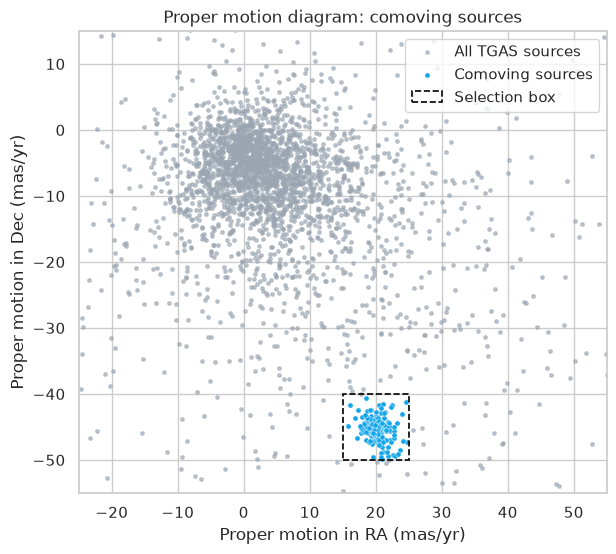

In [39]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(catalog_data['pmra'], catalog_data['pmdec'],
           s=6, color=COLORS["all"], alpha=0.6, label="All TGAS sources")
ax.scatter(comoving['pmra'], comoving['pmdec'],
           s=14, color=COLORS["comoving"], edgecolors="white", linewidth=0.3,
           label="Comoving sources")

# Draw the selection box, using the same limits as in the previous cell
ax.add_patch(Rectangle((pmra_min, pmdec_min), pmra_max - pmra_min, pmdec_max - pmdec_min,
                       fill=False, edgecolor="black", linestyle="--", linewidth=1.2,
                       label="Selection box"))

ax.set_xlim(-25, 55)
ax.set_ylim(-55, 15)
ax.set_aspect("equal")
ax.set_xlabel("Proper motion in RA (mas/yr)")
ax.set_ylabel("Proper motion in Dec (mas/yr)")
ax.set_title("Proper motion diagram: comoving sources")
ax.legend(loc="upper right")
plt.show()

---
## Block 3: Identification of Pleiades members

We will now use the parallax to refine the selection and identify the Pleiades members. Let's look at the parallax distribution of the comoving sources:

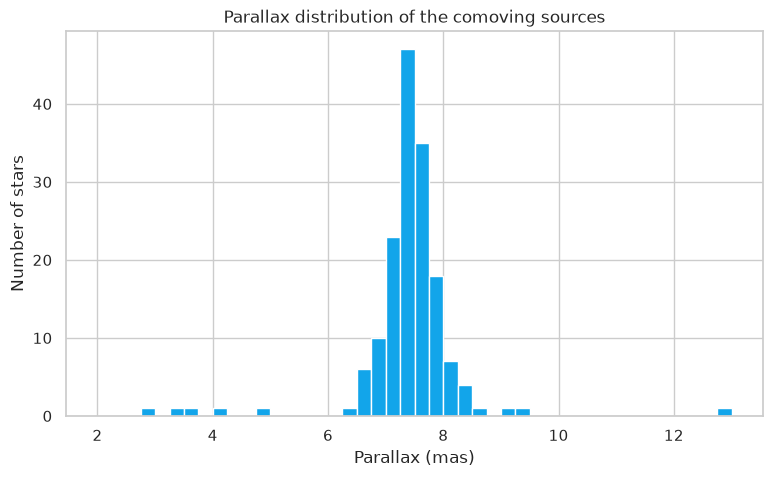

In [40]:
# Parallax bins of 0.25 mas covering all the comoving sources.
# We reuse them in the next histograms, so all of them can be compared directly.
plx_bins = np.arange(np.floor(comoving['parallax'].min()),
                     np.ceil(comoving['parallax'].max()) + 0.25, 0.25)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(comoving['parallax'], bins=plx_bins, color=COLORS["comoving"], edgecolor="white")

ax.set_xlabel("Parallax (mas)")
ax.set_ylabel("Number of stars")
ax.set_title("Parallax distribution of the comoving sources")
plt.show()

There are some outliers, most likely not cluster members. We want to exclude those parallax
outliers, and limit our sources to parallaxes between 6
and 9. We will name this new list of sources as '*cluster*'.

In [42]:
# Parallax limits for the cluster members (mas)
plx_min, plx_max = 6, 9

# Select stars in the cluster
cluster_mask = (
    (comoving['parallax'] > plx_min) &
    (comoving['parallax'] < plx_max)
)

# Extract cluster sources
cluster = comoving[cluster_mask]

cluster[['hip', 'tycho2_id', 'ra', 'dec', 'parallax', 'parallax_error','pmra','pmdec','phot_g_mean_mag']]

hip,tycho2_id,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_mag
str5,str11,float64,float64,float64,float64,float64,float64,float64
--,1800-1908-1,56.613754,24.254813,7.74,0.32,19.96,-44.29,7.36
--,1800-1935-1,56.791982,24.276466,7.15,0.43,20.43,-43.95,9.33
--,1800-1607-1,56.830695,24.138932,7.64,0.3,17.88,-43.46,8.24
--,1800-2201-1,56.837754,24.11608,7.88,0.46,20.89,-44.68,6.33
--,1800-1579-1,56.767652,23.995026,7.13,0.32,22.72,-44.93,8.31
17704,--,56.872808,24.288143,7.57,0.4,18.48,-46.91,6.83
--,1799-79-1,56.465239,24.038689,7.41,0.25,19.72,-44.88,7.84
--,1799-26-1,56.359021,24.034958,8.23,0.3,21.31,-46.95,8.01
--,1800-1567-1,56.851815,23.91449,7.65,0.3,18.85,-43.76,7.31


Let's see how the plot looks now. The shaded band marks the parallax limits we have used:

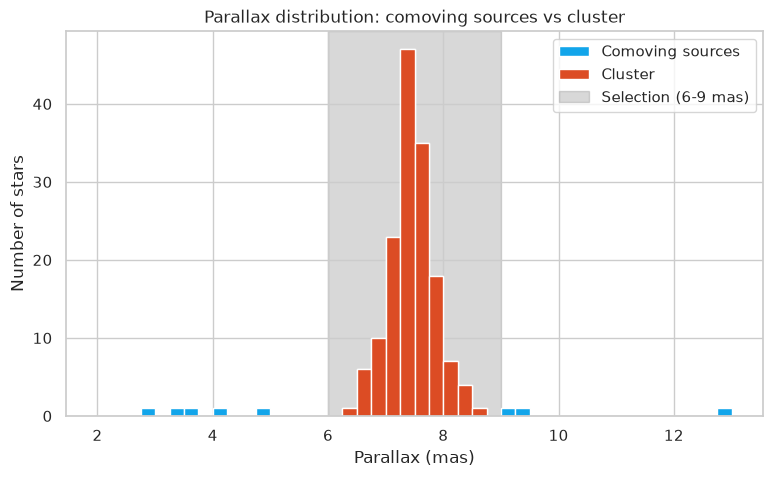

In [45]:
fig, ax = plt.subplots(figsize=(9, 5))

# The cluster is a subset of the comoving sources, so we draw it on top
ax.hist(comoving['parallax'], bins=plx_bins, color=COLORS["comoving"], edgecolor="white",
        label="Comoving sources")
ax.hist(cluster['parallax'], bins=plx_bins, color=COLORS["cluster"], edgecolor="white",
        label="Cluster")

# Shade the parallax range we have selected
ax.axvspan(plx_min, plx_max, color="grey", alpha=0.3, zorder=0,
           label=f"Selection ({plx_min}-{plx_max} mas)")

ax.set_xlabel("Parallax (mas)")
ax.set_ylabel("Number of stars")
ax.set_title("Parallax distribution: comoving sources vs cluster")
ax.legend(loc="upper right")
plt.show()

---
## Block 4: Calculating the distance to Pleiades

In order to calculate realistic distances to the Pleiades, we need accurate parallaxes. Distance in parsec is the reciprocal of parallax
in arcsec:

$$d\,[\mathrm{pc}] = \frac{1}{\varpi\,[\mathrm{arcsec}]} = \frac{1000}{\varpi\,[\mathrm{mas}]}$$

However, inverting parallaxes to get distances is problematic if parallax errors are large, let's say, larger than 10%. Thus, in the next step, we will keep only sources with good parallaxes.

In [46]:
# Select stars with good distance (parallax error smaller than 10%)
distance_mask = (
    (cluster['parallax_error']/cluster['parallax'] < 0.1)
)

good_distance = cluster[distance_mask]

# Compute the distance in parsec (the parallax is in mas)
good_distance['distance'] = 1000 / good_distance['parallax']
good_distance['distance'] = good_distance['distance'].round(2)

good_distance[['hip', 'tycho2_id', 'ra', 'dec', 'parallax', 'parallax_error','pmra','pmdec','phot_g_mean_mag','distance']]

# Optional: uncomment the following lines to save the table as a CSV file
# Convert the data to a pandas DataFrame
#df = good_distance.to_pandas()
# Save the DataFrame as a CSV file
#df.to_csv('good_distance.csv', index=False)

hip,tycho2_id,ra,dec,parallax,parallax_error,pmra,pmdec,phot_g_mean_mag,distance
str5,str11,float64,float64,float64,float64,float64,float64,float64,float64
--,1800-1908-1,56.613754,24.254813,7.74,0.32,19.96,-44.29,7.36,129.2
--,1800-1935-1,56.791982,24.276466,7.15,0.43,20.43,-43.95,9.33,139.86
--,1800-1607-1,56.830695,24.138932,7.64,0.3,17.88,-43.46,8.24,130.89
--,1800-2201-1,56.837754,24.11608,7.88,0.46,20.89,-44.68,6.33,126.9
--,1800-1579-1,56.767652,23.995026,7.13,0.32,22.72,-44.93,8.31,140.25
17704,--,56.872808,24.288143,7.57,0.4,18.48,-46.91,6.83,132.1
--,1799-79-1,56.465239,24.038689,7.41,0.25,19.72,-44.88,7.84,134.95
--,1799-26-1,56.359021,24.034958,8.23,0.3,21.31,-46.95,8.01,121.51
--,1800-1567-1,56.851815,23.91449,7.65,0.3,18.85,-43.76,7.31,130.72


Now we plot the results, together with a Gaussian fit to the good parallaxes:

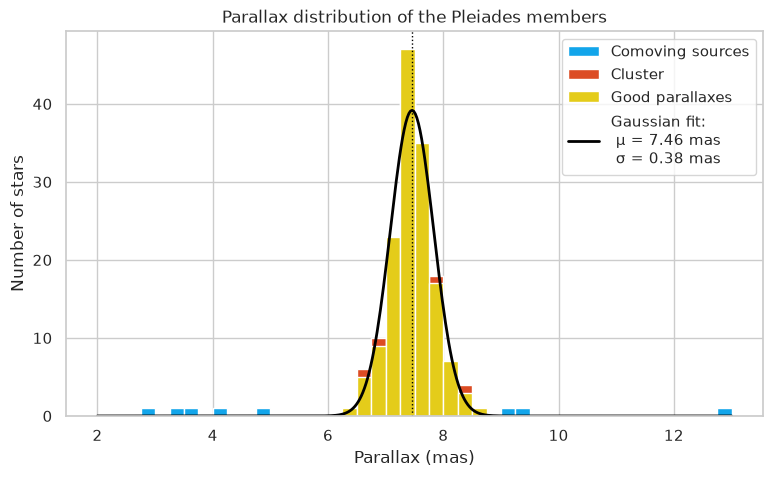

In [56]:
fig, ax = plt.subplots(figsize=(9, 5))

# Each sample is a subset of the previous one, so we draw them from largest to smallest
ax.hist(comoving['parallax'], bins=plx_bins, color=COLORS["comoving"], edgecolor="white",
        label="Comoving sources")
ax.hist(cluster['parallax'], bins=plx_bins, color=COLORS["cluster"], edgecolor="white",
        label="Cluster")
ax.hist(good_distance['parallax'], bins=plx_bins, color=COLORS["good"], edgecolor="white",
        label="Good parallaxes")

# Gaussian fit to the good parallaxes
mu, std = norm.fit(good_distance['parallax'])

# The Gaussian is a probability density (area = 1). To compare it with the histogram
# we multiply it by the number of stars and by the bin width.
x = np.linspace(plx_bins[0], plx_bins[-1], 400)
bin_width = plx_bins[1] - plx_bins[0]
gauss = norm.pdf(x, mu, std) * len(good_distance) * bin_width

ax.plot(x, gauss, color="black", linewidth=2,
        label=f"Gaussian fit:\n μ = {mu:.2f} mas \n σ = {std:.2f} mas")
ax.axvline(mu, color="black", linestyle=":", linewidth=1)

ax.set_xlabel("Parallax (mas)")
ax.set_ylabel("Number of stars")
ax.set_title("Parallax distribution of the Pleiades members")
ax.legend(loc="upper right")
plt.show()

How far away is the Pleiades open cluster? Let's calculate the mean distance using sources with good parallaxes.

In [57]:
# Compute mean and standard deviation

mean_distance = good_distance['distance'].mean()
std_distance = good_distance['distance'].std()

print("="*50)
print(f"\033[1;32mDistance (mean): {mean_distance:.2f} pc\033[0m")
print(f"\033[1;31mDistance (standard deviation): {std_distance:.2f} pc\033[0m")

print("="*50)

Distance (mean): 134.45 pc
Distance (standard deviation): 6.85 pc


Finally, we will visualize the sources we have identified as Pleiades members in an interactive cube plot:

In [58]:
# Create the interactive 3D plot (you can rotate and zoom it with the mouse)
fig = px.scatter_3d(
    good_distance.to_pandas(),
    x='ra',
    y='dec',
    z='distance',
    color='distance',
    color_continuous_scale='Viridis',
    labels={'ra': 'RA (deg)', 'dec': 'Dec (deg)', 'distance': 'Distance (pc)'},
    title="Pleiades members: RA, Dec and distance",
)

fig.update_traces(marker=dict(size=4, opacity=0.85))
fig.update_layout(
    template='plotly_white',  # same white style as the rest of the plots
    margin=dict(r=10, b=10, l=10, t=40),
)

fig.show()

---
## Bonus

### Bonus 1: How many stars have 2MASS photometry?

In order to answer this question, we can query the 2MASS-PSC catalog and then perform a cross-match with the sources we have obtained:

In [59]:
#Search 2MASS-PSC catalogs

Vizier.find_catalogs("2MASS-PSC")

OrderedDict([('II/246', </>), ('II/281', </>)])

The 2MASS-PSC catalogue is `II/246`. Let's obtain the coordinates of the sources in `good_distance` and then query the 2MASS-PSC catalog around each one of those coordinates (this cell can take a few minutes, as it sends one query per source).

In [71]:
# Search radius for the cross-match
search_radius = 5 * u.arcsec

# Table with our sources, plus an index to link each match back to its source
upload = good_distance['ra', 'dec'].copy()
upload['source_idx'] = np.arange(len(upload))

# A single request to the CDS X-Match service: all 2MASS sources within 5" of each of ours
xmatch = XMatch.query(cat1=upload, cat2='vizier:II/246/out',
                      max_distance=search_radius, colRA1='ra', colDec1='dec')

# Keep only the closest 2MASS counterpart for each of our sources
matched_results = (xmatch.to_pandas()
                   .sort_values('angDist')
                   .drop_duplicates(subset='source_idx', keep='first')
                   .sort_values('source_idx')
                   .reset_index(drop=True))
matched_results

,angDist,ra,dec,source_idx,2MASS,RAJ2000,DEJ2000,errHalfMaj,errHalfMin,errPosAng,Jmag,Hmag,Kmag,e_Jmag,e_Hmag,e_Kmag,Qfl,Rfl,X,MeasureJD
0,0.834140,56.613754,24.254813,0,03462728+2415181,56.613671,24.255032,0.07,0.06,90.0,7.119,7.111,7.125,0.018,0.017,0.024,AAA,111,0,2.451139e+06
1,0.795844,56.791982,24.276466,1,03471005+2416360,56.791894,24.276672,0.07,0.06,0.0,8.533,8.329,8.282,0.026,0.036,0.024,AAA,111,0,2.451812e+06
2,0.735286,56.830695,24.138932,2,03471935+2408208,56.830625,24.139126,0.07,0.06,0.0,7.767,7.627,7.639,0.029,0.038,0.020,AAA,111,0,2.451812e+06
3,0.861198,56.837754,24.116080,3,03472103+2406586,56.837662,24.116304,0.07,0.06,0.0,6.228,6.248,6.257,0.019,0.029,0.021,AAA,111,0,2.451812e+06
4,0.624413,56.767652,23.995026,4,03470421+2359426,56.767553,23.995174,0.07,0.06,0.0,7.770,7.658,7.642,0.018,0.051,0.023,AAA,111,0,2.451812e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143,0.980278,52.868203,21.821717,143,03312833+2149190,52.868053,21.821951,0.06,0.06,90.0,8.071,7.890,7.824,0.023,0.017,0.023,AAA,111,0,2.450749e+06
144,0.865897,59.507154,20.676596,144,03580169+2040365,59.507069,20.676823,0.08,0.06,90.0,8.436,8.248,8.197,0.024,0.020,0.031,AAA,111,0,2.450751e+06
145,0.727928,52.236363,26.308430,145,03285670+2618309,52.236250,26.308605,0.08,0.07,0.0,7.741,7.681,7.593,0.035,0.063,0.021,AAA,111,0,2.451812e+06
146,0.691976,56.257017,19.559188,146,03450166+1933337,56.256958,19.559372,0.08,0.07,90.0,8.404,8.225,8.152,0.021,0.031,0.021,AAA,111,0,2.451128e+06


In [72]:
print("Sources in our list:", len(good_distance))
print("Sources with 2MASS photometry:", len(matched_results))

Sources in our list: 148
Sources with 2MASS photometry: 148


### Bonus 2: Compare with another study

We can also compare our resulting member list with another census of Pleiades members to see how many objects they have in common. As an example, we will cross-match our table with a catalogue from VizieR.

Let's select our catalog by searching it by keyword:

In [63]:
Vizier.find_catalogs("Pleiades")

OrderedDict([('I/90', </>),
             ('I/163', </>),
             ('I/258', </>),
             ('II/131', </>),
             ('J/ApJ/348/557', </>),
             ('J/ApJ/602/L117', </>),
             ('J/ApJ/822/81', </>),
             ('J/ApJ/901/91', </>),
             ('J/ApJ/904/140', </>),
             ('J/ApJ/916/66', </>),
             ('J/ApJ/921/117', </>),
             ('J/ApJ/923/23', </>),
             ('J/ApJ/926/132', </>),
             ('J/ApJS/85/315', </>),
             ('J/ApJS/91/625', </>),
             ('J/ApJS/102/75', </>),
             ('J/ApJS/172/663', </>),
             ('J/A+A/299/696', </>),
             ('J/A+A/320/74', </>),
             ('J/A+A/323/139', </>),
             ('J/A+A/329/101', </>),
             ('J/A+A/332/575', </>),
             ('J/A+A/335/183', </>),
             ('J/A+A/341/751', </>),
             ('J/A+A/400/891', </>),
             ('J/A+A/410/671', </>),
             ('J/A+A/416/125', </>),
             ('J/A+A/463/579', </>),

Select catalog `J/ApJS/172/663` (Stauffer+ 2007).

In [64]:
Vizier.get_catalogs("J/ApJS/172/663")

TableList with 4 tables:
	'0:J/ApJS/172/663/table2' with 15 column(s) and 50 row(s) 
	'1:J/ApJS/172/663/table5' with 11 column(s) and 50 row(s) 
	'2:J/ApJS/172/663/table4' with 8 column(s) and 50 row(s) 
	'3:J/ApJS/172/663/notes' with 2 column(s) and 34 row(s) 

We are interested in Table 2, so let's select only that table:

In [65]:
#We select to have no limit in our output by setting it to -1:
Vizier.ROW_LIMIT = -1
#The [0] at the end of the line selects only the first element in the table list, which is table 2 from the catalog as we have seen
catalog_data2=Vizier.get_catalogs("J/ApJS/172/663/table2")[0]
catalog_data2

RAJ2000,DEJ2000,Jmag,q_Jmag,Hmag,q_Hmag,Ksmag,q_Ksmag,r_Ksmag,2M,Bmag,Vmag,Icmag,Ref,SimbadName
deg,deg,mag,,mag,,mag,,,,mag,mag,mag,,
float64,float64,float32,str1,float32,str1,float32,str1,uint8,str2,float32,float32,float32,int16,str25
51.898273,24.528660,10.781,A,10.066,A,9.892,A,1,2M,--,--,11.85,22,Cl* Melotte 22 DH 001
51.925262,23.803688,9.066,A,8.754,A,8.679,A,1,2M,10.96,10.30,--,4,Cl* Melotte 22 PELS 121
51.976067,24.936478,12.880,A,12.219,A,11.981,A,1,2M,--,--,14.34,22,Cl* Melotte 22 DH 003
52.006481,23.078499,13.525,A,12.919,A,12.619,A,1,2M,--,--,15.05,22,Cl* Melotte 22 DH 004
52.168613,25.607782,10.198,A,9.883,A,9.723,A,1,2M,12.59,11.75,--,9,Cl* Melotte 22 AK III-59
52.200249,25.575842,13.072,A,12.442,A,12.153,A,1,2M,--,--,14.75,22,Cl* Melotte 22 DH 006
52.203186,26.499350,10.429,A,10.006,A,9.924,A,1,2M,--,--,11.16,22,Cl* Melotte 22 DH 007
52.355843,25.652304,8.459,A,8.314,A,8.270,A,1,2M,9.90,9.43,--,9,Cl* Melotte 22 AK III-79


Let's now perform a pair match, setting the max distance to 2.0 arcsec this time.

In [66]:
# First, we convert to SkyCoord objects. Lets call "gd" to those of the "good distance" sources, and "c2" to those of "catalog data 2"
coords_gd = SkyCoord(good_distance["ra"], good_distance["dec"], unit=(u.deg, u.deg))
coords_c2 = SkyCoord(catalog_data2["RAJ2000"], catalog_data2["DEJ2000"], unit=(u.deg, u.deg))

# Define matching radius
radius = 2 * u.arcsec

# Perform the pair match by using search_around_sky with the coordinates we have obtained,
# in return we obtain the index in each table that corresponds to the matching source
# in the other table, as well as the separations on-sky and 3D, which we set in blank as we won't need them.
# Note the order of the output: first the indices in the catalogue we search in (c2), then the indices in our table (gd)
idx_c2, idx_gd, _, _ = coords_gd.search_around_sky(coords_c2, radius)

How many objects are confirmed as kinematical members of the Pleiades?

In [67]:
print("Sources in our list:", len(good_distance))
print("Sources in common with Stauffer+ 2007:", len(idx_c2))

Sources in our list: 148
Sources in common with Stauffer+ 2007: 119


These are the sources in common, as they appear in the Stauffer+ 2007 catalogue:

In [68]:
catalog_data2[idx_c2]

RAJ2000,DEJ2000,Jmag,q_Jmag,Hmag,q_Hmag,Ksmag,q_Ksmag,r_Ksmag,2M,Bmag,Vmag,Icmag,Ref,SimbadName
deg,deg,mag,,mag,,mag,,,,mag,mag,mag,,
float64,float64,float32,str1,float32,str1,float32,str1,uint8,str2,float32,float32,float32,int16,str25
52.409874,24.510546,10.318,A,9.856,A,9.698,A,1,2M,--,--,11.19,22,Cl* Melotte 22 DH 008
52.890076,26.265507,9.514,A,9.222,A,9.068,A,1,2M,11.45,10.77,--,4,Cl* Melotte 22 PELS 008
53.274277,22.134232,9.897,A,9.522,A,9.425,A,1,2M,12.25,11.43,--,4,Cl* Melotte 22 PELS 004
53.307938,23.006475,10.259,A,9.787,A,9.669,A,1,2M,12.93,11.98,--,4,Cl* Melotte 22 PELS 123
53.507523,24.880957,9.582,A,9.269,A,9.178,A,1,2M,11.58,10.88,--,4,Cl* Melotte 22 PELS 005
53.530495,24.344501,8.553,A,8.312,A,8.274,A,1,2M,10.08,9.57,--,4,Cl* Melotte 22 PELS 006
53.882030,22.823627,8.831,A,8.599,A,8.541,A,1,2M,10.40,9.86,--,4,Cl* Melotte 22 PELS 124
54.350204,22.350985,8.141,A,7.946,A,7.902,A,1,2M,9.71,9.20,--,4,Cl* Melotte 22 PELS 003


In the following histogram we can see how our sources are among the brightest sources in the Stauffer+ 2007 catalogue. This is because TGAS is a shallow survey with a limiting magnitude around B=13.

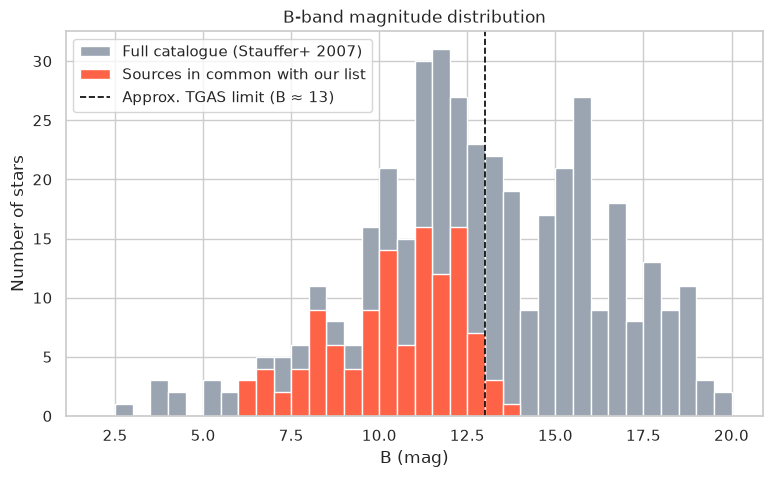

In [70]:
# B magnitudes of the full catalogue and of the sources in common.
# Some stars have no B magnitude (masked values), so we remove them first.
b_all = np.ma.compressed(catalog_data2['Bmag'])
b_common = np.ma.compressed(catalog_data2[idx_c2]['Bmag'])

# Use the same bins for both histograms, so they can be compared
b_bins = np.arange(np.floor(b_all.min()), np.ceil(b_all.max()) + 0.5, 0.5)

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(b_all, bins=b_bins, color=COLORS["all"], edgecolor="white",
        label="Full catalogue (Stauffer+ 2007)")
ax.hist(b_common, bins=b_bins, color="tomato", edgecolor="white",
        label="Sources in common with our list")

# Approximate limiting magnitude of TGAS
ax.axvline(13, color="black", linestyle="--", linewidth=1.2, label="Approx. TGAS limit (B ≈ 13)")

ax.set_xlabel("B (mag)")
ax.set_ylabel("Number of stars")
ax.set_title("B-band magnitude distribution")
ax.legend(loc="upper left")
plt.show()

### Bonus 3: What do these stars look like?

Let's use now Aladin to visualize the position in the sky of our 148 sources (table `good_distance`).

In [ ]:
#Load a sky map in Aladin:
aladin1 = Aladin(
    survey="Collection/Images/Optical/DSS colored",
    fov=9,
    target="Pleiades"
)
aladin1


Once the sky map is displayed, we overplot our sources on it (go back to the map above to see them):

In [31]:
aladin1.add_table(good_distance, name="Pleiades sources")

---
## Even more

Many other functionalities are available in TOPCAT: concatenate tables, cross-match multiple tables,
save tables in LaTeX format, and many more…. For further information in these and many more functionalities, we refer the user to the TOPCAT manual web page:

http://www.star.bristol.ac.uk/~mbt/topcat/